### 1. 필요 패키지 설치

In [1]:
!uv add pandas numpy scikit-learn matplotlib seaborn

# uv pip list에도 뜨는것 확인함

Resolved 115 packages in 1ms
Audited 111 packages in 11ms


### 2. 데이터 파일 로드 후 데이터 확인

In [2]:
import pandas as pd

df = pd.read_csv('titanic.csv')

print("=== Shape ===")
print(df.shape)

print("\n=== Head ===")
display(df.head())

print("\n=== Info ===")
df.info()

print("\n=== 결측치 ===")
print(df.isnull().sum())

print("\n=== 기초통계 ===")
display(df.describe())

=== Shape ===
(891, 12)

=== Head ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

=== 결측치 ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtyp

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


`Survived`가 타겟(y)이고, 나머지가 feature(X)이다.

#### 결측치 확인
`Age` : 177개. 중앙값으로 채운다
`Cabin`: 거의 대부분인 687개가 결측치이므로, 컬럼을 제거한다.
`Embarked`: 2개. 최빈값으로 채운다

#### 분석과 무관한 컬럼 제거
`Name`, `Ticket`, `PassengerId`는 분석에 불필요하므로 제거한다.

위 두 개의 작업은 **Pipeline 내에서 수행**한다.

#### 수치형/범주형 데이터 확인
`Sex`, `Embarked`는 범주형 데이터이다. 
`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`는 수치형 데이터이다.
    

In [4]:
# 최종 데이터셋 확인

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


None

### 4. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split
X = df.drop(['Survived'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 7) (179, 7) (712,) (179,)


### 5. 파이프라인 설정 및 학습

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

# ── 컬럼 정의 ───────────────────────────────────────────────
num_features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
cat_features = ['Sex', 'Embarked']
drop_features = ['Cabin', 'Name', 'Ticket', 'PassengerId']

# ── 실험 옵션 정의 ──────────────────────────────────────────
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler'  : MinMaxScaler(),
    'NoScaler'      : 'passthrough',
}

models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
}

# ── Pipeline 생성 함수 ──────────────────────────────────────
def build_pipeline(scaler, model):
    num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),  # Age 결측치
        ('scaler', scaler),
    ])
    
    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Embarked 결측치
        ('encoder', OneHotEncoder()),
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('drop', 'drop', drop_features),             # 불필요 컬럼 제거
    ])
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

# ── 학습 + 결과 저장 (한 번만) ──────────────────────────────
results = []
trained = {}  # confusion matrix용으로 재사용

for (scaler_name, scaler), (model_name, model) in product(scalers.items(), models.items()):
    key = f"{scaler_name} + {model_name}"
    pipeline = build_pipeline(scaler, model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        'Scaler'  : scaler_name,
        'Model'   : model_name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1'      : round(f1_score(y_test, y_pred), 4),
    })
    trained[key] = y_pred  # 예측값 저장

### 6. 결과 확인

,Scaler,Model,Accuracy,F1
0,StandardScaler,SVM,0.8156,0.7660
1,StandardScaler,KNN,0.8101,0.7606
2,MinMaxScaler,KNN,0.8045,0.7586
3,MinMaxScaler,SVM,0.7933,0.7176
4,NoScaler,KNN,0.7263,0.6142
5,NoScaler,SVM,0.6592,0.3838


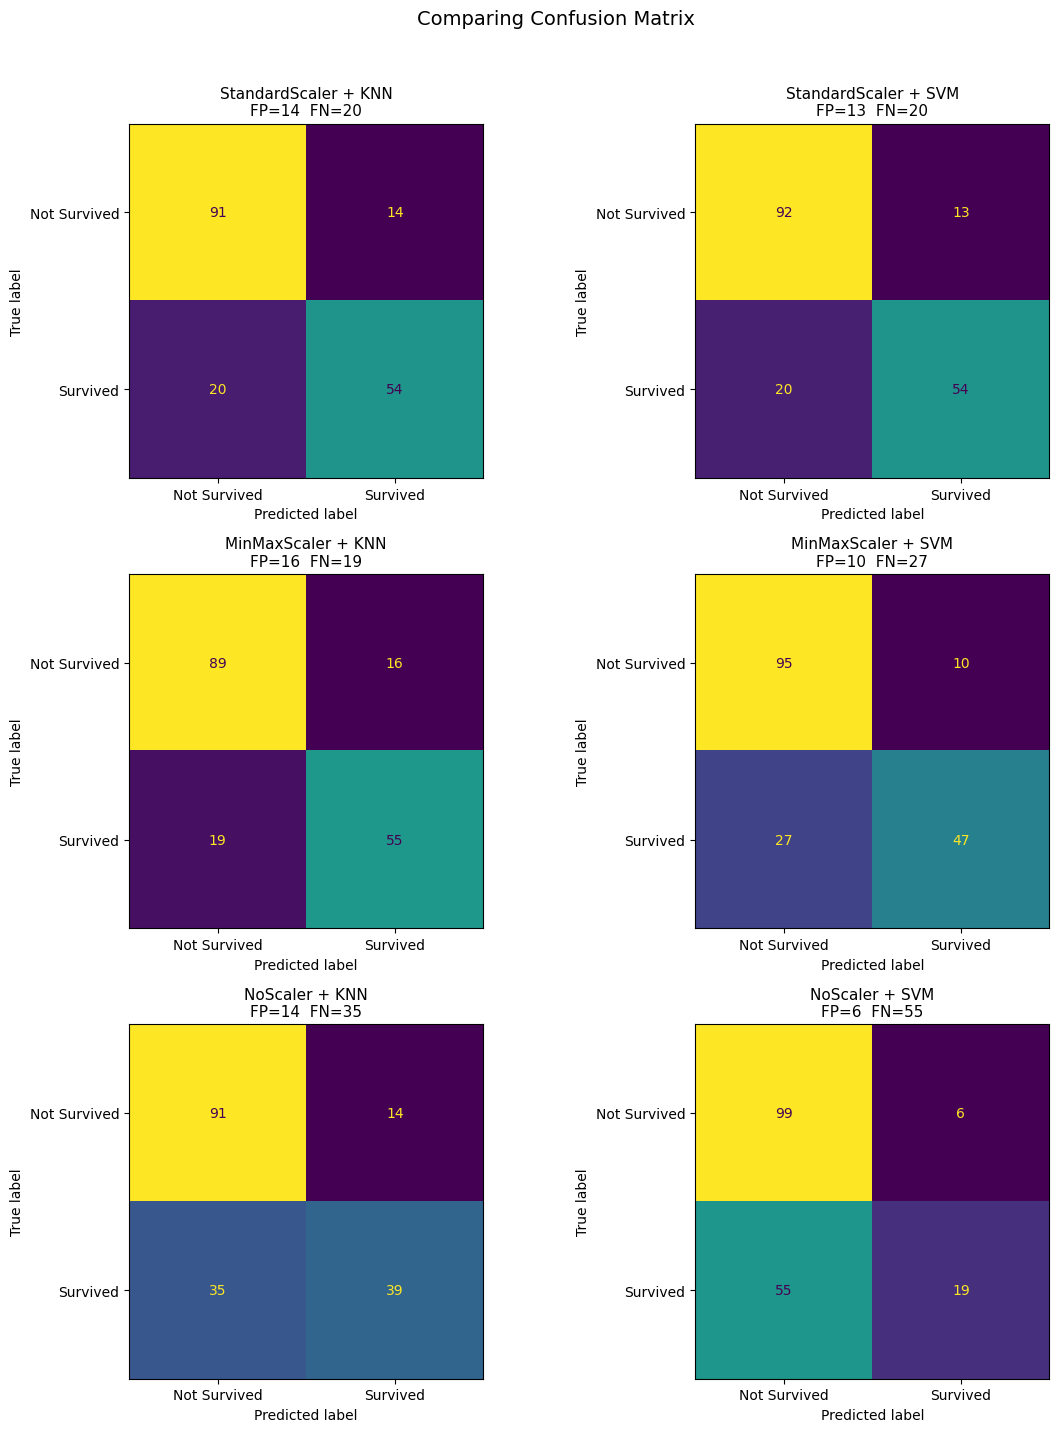

In [7]:
# ── 결과 테이블 ─────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
display(results_df)

# ── Confusion Matrix ────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for ax, (key, y_pred) in zip(axes.flatten(), trained.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived']).plot(ax=ax, colorbar=False)

    # 오분류 수 강조
    fp = cm[0][1]  # 실제 Not Survived → Survived 예측
    fn = cm[1][0]  # 실제 Survived → Not Survived 예측
    ax.set_title(f"{key}\nFP={fp}  FN={fn}", fontsize=11)

plt.suptitle("Comparing Confusion Matrix", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()